<center><h1>Soundalgekar_Abhishek_Project</h1></center>

Name: Abhishek Soundalgekar
<br>
Github Username: ABHISHEK SOUNDALGEKAR
<br>
USC ID: 2089011000

Import Packages

In [1]:
pip install -r ../requirements.txt

  Preparing metadata (setup.py) ... done
  Using cached imageio-2.37.0-py3-none-any.whl.metadata (5.2 kB)
  Using cached lazy_loader-0.4-py3-none-any.whl.metadata (7.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 31.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 31.1 MB/s eta 0:00:00a 0:00:01
Using cached imageio-2.37.0-py3-none-any.whl (315 kB)
Using cached lazy_loader-0.4-py3-none-any.whl (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.3 MB/s eta 0:00:00
  DEPRECATION: Building 'bootstrapped' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'bootst

In [2]:
import os
import random
import shutil
from pathlib import Path
from typing import Tuple, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import (ResNet50,ResNet101,VGG16,EfficientNetB0)
from tensorflow.keras.layers import (Input,GlobalAveragePooling2D,Dense,Dropout,BatchNormalization,Activation)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, Adam as AdamOpt
from tensorflow.keras.callbacks import (EarlyStopping,ReduceLROnPlateau,ModelCheckpoint
)
from tensorflow.keras.regularizers import l2
from sklearn.metrics import classification_report

import efficientnet.tfkeras as efn
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.regularizers import l2
from tensorflow.keras import Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.metrics import AUC

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# First Model - Resnet50 #

In [3]:
from pathlib import Path
import shutil, random

def split_into_train_val_test(src_root: Path, dst_root: Path, train_frac=0.8, val_frac_of_train=0.2, seed=123):
    random.seed(seed)
    for cls in sorted((src_root).iterdir()):
        if not cls.is_dir(): continue
        imgs = sorted(cls.iterdir())
        n = len(imgs)
        split_pt = int(train_frac * n)
        train_imgs = imgs[:split_pt]
        test_imgs  = imgs[split_pt:]

        # from train_imgs, take a random val set
        n_val = int(val_frac_of_train * len(train_imgs))
        val_imgs = random.sample(train_imgs, n_val)
        train_imgs = [i for i in train_imgs if i not in val_imgs]

        for subset, files in [("train", train_imgs), ("val", val_imgs), ("test", test_imgs)]:
            for p in files:
                dst = dst_root / subset / cls.name
                dst.mkdir(parents=True, exist_ok=True)
                shutil.copy2(p, dst / p.name)

# Usage:
split_into_train_val_test(
    src_root=Path("../data/RealWaste"),       # your original data folder
    dst_root=Path("../data/WasteSplit")
)

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def preprocess_with_contrast(x):
    # x is a float32 image in [0,255]
    x = tf.image.random_contrast(x, lower=0.8, upper=1.2)
    return tf.keras.applications.resnet50.preprocess_input(x)

augmentor = ImageDataGenerator(
    preprocessing_function=preprocess_with_contrast,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    brightness_range=(0.8, 1.2),
    horizontal_flip=True
)


In [5]:
DATA_ROOT: Path = Path("../data/WasteSplit")
IMG_DIMS: Tuple[int,int] = (224, 224)
BATCH_SZ: int = 5
NUM_EPOCHS: int = 100

#Augmentation + ResNet50 Preprocessing
augmenter = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input,
    rotation_range=20,            
    width_shift_range=0.2,        
    height_shift_range=0.2,       
    zoom_range=0.2,               
    brightness_range=(0.8, 1.2),  
    horizontal_flip=True
)

def make_generator(
    split: str,
    batch_size: int = BATCH_SZ,
    img_size: Tuple[int,int] = IMG_DIMS,
    shuffle: bool = True
) -> tf.keras.preprocessing.image.DirectoryIterator:
    folder = DATA_ROOT / split
    return augmenter.flow_from_directory(
        directory=str(folder),
        target_size=img_size,
        batch_size=batch_size,
        class_mode="categorical",
        shuffle=shuffle
    )

train_generator = make_generator("train",  batch_size=BATCH_SZ, img_size=IMG_DIMS, shuffle=True)
val_generator   = make_generator("val",    batch_size=BATCH_SZ, img_size=IMG_DIMS, shuffle=False)
test_generator  = make_generator("test",   batch_size=BATCH_SZ, img_size=IMG_DIMS, shuffle=False)

Found 3042 images belonging to 9 classes.
Found 756 images belonging to 9 classes.
Found 954 images belonging to 9 classes.


In [6]:
root_path    = Path("../data/WasteSplit")
train_path   = root_path / "train"
height_px    = 224
width_px     = 224
channels_cnt = 3
input_dims   = (height_px, width_px, channels_cnt)

#Class Count
label_count = sum(1 for d in train_path.iterdir() if d.is_dir())

#Freeze Pretrained Backbone
resnet_core = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=input_dims,
    name="resnet50_core"
)
resnet_core.trainable = False

l2_penalty = l2(1e-2)

#Dense → BatchNorm → ReLU Helper
def dense_norm_relu(tensor, units, identifier: str):
    y = Dense(units, kernel_regularizer=l2_penalty, name=f"{identifier}_dense")(tensor)
    y = BatchNormalization(name=f"{identifier}_bn")(y)
    return Activation("relu", name=f"{identifier}_act")(y)

#Classification Head
x = GlobalAveragePooling2D(name="avg_pool")(resnet_core.output)
x = dense_norm_relu(x, 256, "blockA")
x = dense_norm_relu(x, 128, "blockB")
x = Dropout(0.2, name="blockC_dropout")(x)
x = dense_norm_relu(x, 64,  "blockC")

# Final prediction layer
output_layer = Dense(label_count, activation="softmax", name="predictions")(x)

waste_classifier = Model(
    inputs=resnet_core.input,
    outputs=output_layer,
    name="WasteSplit_ResNet50"
)
waste_classifier.summary()

2025-07-28 19:32:33.438638: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-07-28 19:32:33.438792: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-07-28 19:32:33.438798: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2025-07-28 19:32:33.439017: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-07-28 19:32:33.439039: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "WasteSplit_ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,155,785 (92.15 MB)

 Trainable params: 567,177 (2.16 MB)

 Non-trainable params: 23,588,608 (89.98 MB)

In [7]:
from tensorflow.keras.optimizers import Adam as OptimizerAdam
from tensorflow.keras.losses     import CategoricalCrossentropy
from tensorflow.keras.metrics    import CategoricalAccuracy

lr_value      = 1e-4
adam_solver   = OptimizerAdam(learning_rate=lr_value)
ce_loss       = CategoricalCrossentropy()
cat_accuracy  = CategoricalAccuracy(name="categorical_accuracy")

classification_engine = waste_classifier
classification_engine.compile(
    optimizer=adam_solver,
    loss=ce_loss,
    metrics=[cat_accuracy]
)

In [8]:
from tensorflow.keras.metrics import AUC
from tensorflow.keras.callbacks import Callback, EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, Dense, BatchNormalization, Dropout, Activation
)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
import tensorflow as tf
from pathlib import Path

DATA_DIR = Path("../data/WasteSplit")
H, W     = 224, 224
BATCH    = 5
EPOCHS   = 100
LR       = 1e-4
L2_REG   = 1e-2
PATIENCE = 40

def make_stream(subdir, augment=False):
    args = dict(
        preprocessing_function=tf.keras.applications.resnet.preprocess_input,
        rotation_range=20, width_shift_range=0.2,
        height_shift_range=0.2, zoom_range=0.2,
        brightness_range=(0.8,1.2), horizontal_flip=True
    ) if augment else dict(preprocessing_function=tf.keras.applications.resnet.preprocess_input)
    gen = ImageDataGenerator(**args)
    return gen.flow_from_directory(
        DATA_DIR / subdir,
        target_size=(H, W),
        batch_size=BATCH,
        class_mode="categorical",
        shuffle=(subdir == "train")
    )

train_stream      = make_stream("train", augment=True)
validation_stream = make_stream("val",   augment=True)

# model with AUC
backbone = ResNet50(include_top=False, weights="imagenet", input_shape=(H, W, 3))
backbone.trainable = False

def dense_block(x, units, tag):
    x = Dense(units, kernel_regularizer=l2(L2_REG), name=f"{tag}_dense")(x)
    x = BatchNormalization(name=f"{tag}_bn")(x)
    return Activation("relu", name=f"{tag}_act")(x)

x = GlobalAveragePooling2D()(backbone.output)
x = dense_block(x, 256, "blk1")
x = dense_block(x, 128, "blk2")
x = Dropout(0.2)(x)
x = dense_block(x, 64,  "blk3")
outputs = Dense(train_stream.num_classes, activation="softmax")(x)

model = Model(backbone.input, outputs, name="resnet50_waste")
model.compile(
    optimizer=Adam(LR),
    loss="categorical_crossentropy",
    metrics=["accuracy", AUC(name="auc")]
)

#Callbacks
stop_callback = EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1
)

class LearningRateLogger(Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        logs["learning_rate"] = float(self.model.optimizer.learning_rate.numpy())

lr_logger = LearningRateLogger()

#Train with verbose=1
history = model.fit(
    train_stream,
    validation_data=validation_stream,
    epochs=EPOCHS,
    callbacks=[stop_callback, lr_logger],
    verbose=1
)

Found 3042 images belonging to 9 classes.
Found 756 images belonging to 9 classes.
Epoch 1/100


/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
2025-07-28 19:32:47.040319: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


609/609 ━━━━━━━━━━━━━━━━━━━━ 33s 48ms/step - accuracy: 0.1787 - auc: 0.5790 - loss: 9.2958 - val_accuracy: 0.5661 - val_auc: 0.8887 - val_loss: 7.9778 - learning_rate: 1.0000e-04
Epoch 2/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.4674 - auc: 0.8350 - loss: 8.1087 - val_accuracy: 0.6746 - val_auc: 0.9365 - val_loss: 7.2065 - learning_rate: 1.0000e-04
Epoch 3/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.5643 - auc: 0.8917 - loss: 7.3866 - val_accuracy: 0.7156 - val_auc: 0.9486 - val_loss: 6.6207 - learning_rate: 1.0000e-04
Epoch 4/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.5828 - auc: 0.9058 - loss: 6.8423 - val_accuracy: 0.7381 - val_auc: 0.9599 - val_loss: 6.0738 - learning_rate: 1.0000e-04
Epoch 5/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.6213 - auc: 0.9218 - loss: 6.2829 - val_accuracy: 0.7566 - val_auc: 0.9625 - val_loss: 5.6048 - learning_rate: 1.0000e-04
Epoch 6/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - 

In [9]:
model.save("resnet50_model_final.keras")

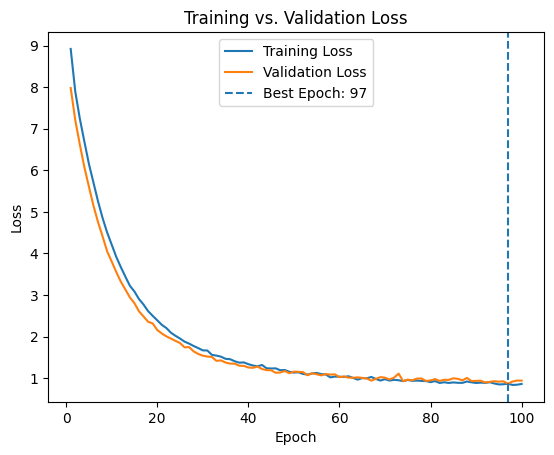

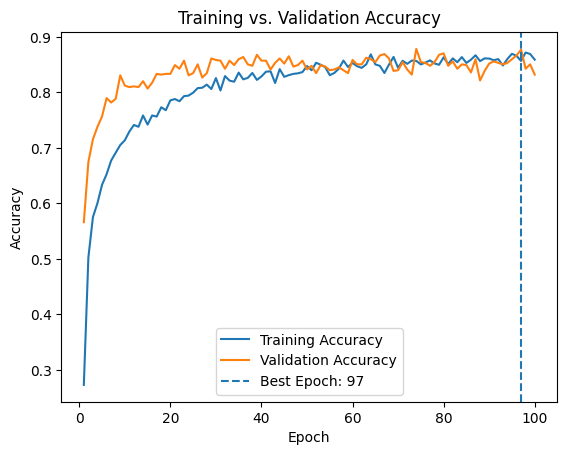

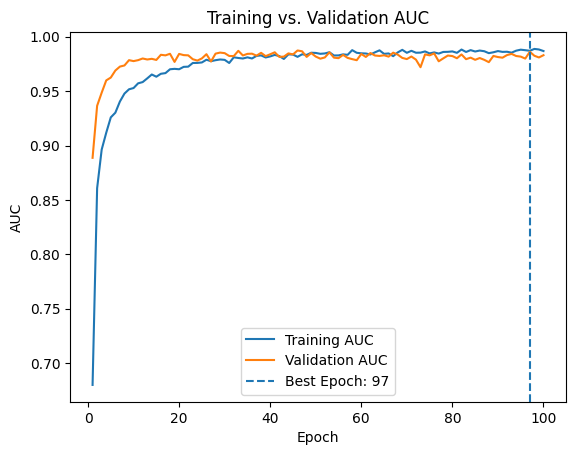

In [10]:
# Convert history to DataFrame 
stats_df = pd.DataFrame(history.history)

#  Extract arrays 
train_losses = stats_df['loss'].to_numpy()
val_losses   = stats_df['val_loss'].to_numpy()
train_accs   = stats_df['accuracy'].to_numpy()
val_accs     = stats_df['val_accuracy'].to_numpy()

# NEW: extract AUC metrics
train_aucs = stats_df['auc'].to_numpy()
val_aucs   = stats_df['val_auc'].to_numpy()

#Epoch index & best epoch 
epochs_list   = np.arange(1, train_losses.size + 1)
best_epoch_ix = int(val_losses.argmin()) + 1

# Loss plot 
plt.figure()
plt.plot(epochs_list, train_losses, label='Training Loss')
plt.plot(epochs_list, val_losses,   label='Validation Loss')
plt.axvline(best_epoch_ix, linestyle='--', label=f'Best Epoch: {best_epoch_ix}')
plt.title('Training vs. Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

#Accuracy plot 
plt.figure()
plt.plot(epochs_list, train_accs, label='Training Accuracy')
plt.plot(epochs_list, val_accs,   label='Validation Accuracy')
plt.axvline(best_epoch_ix, linestyle='--', label=f'Best Epoch: {best_epoch_ix}')
plt.title('Training vs. Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#AUC plot 
plt.figure()
plt.plot(epochs_list, train_aucs, label='Training AUC')
plt.plot(epochs_list, val_aucs,   label='Validation AUC')
plt.axvline(best_epoch_ix, linestyle='--', label=f'Best Epoch: {best_epoch_ix}')
plt.title('Training vs. Validation AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.show()


In [11]:
from sklearn.metrics import classification_report, roc_auc_score
import tensorflow as tf
import pandas as pd
import numpy as np

# Data loader for test set 
test_root = Path("../data/WasteSplit") / "test"
test_only_gen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet50.preprocess_input
).flow_from_directory(
    directory=str(test_root),
    target_size=(H, W),        # Fixed
    batch_size=BATCH,          # Fixed
    class_mode="categorical",
    shuffle=False
)

# Predictions & classification report 
probs_test   = model.predict(test_only_gen, verbose=0)  # Fixed
pred_indices = np.argmax(probs_test, axis=1)
true_indices = test_only_gen.classes

raw_labels    = list(test_only_gen.class_indices.keys())
pretty_labels = [f"{i+1}-{lbl}" for i, lbl in enumerate(raw_labels)]

report_map = classification_report(
    true_indices,
    pred_indices,
    target_names=pretty_labels,
    output_dict=True
)

report_df = pd.DataFrame(report_map).T.round(2)
summaries   = ['accuracy', 'macro avg', 'weighted avg']
class_order = [r for r in report_df.index if r not in summaries]
report_df   = report_df.loc[class_order + summaries]

print("\nResNet50 Test‑Set Classification Report:\n")
print(report_df.to_string())

# Compute & print Macro‑AUC 
y_true_oh = tf.keras.utils.to_categorical(true_indices, num_classes=test_only_gen.num_classes)
macro_auc = roc_auc_score(y_true_oh, probs_test, average='macro', multi_class='ovo')
print(f"\nMacro‑average ROC‑AUC: {macro_auc:.2f}")

Found 954 images belonging to 9 classes.

ResNet50 Test‑Set Classification Report:

                         precision  recall  f1-score  support
1-1-Cardboard                 0.74    0.91      0.82    93.00
2-2-Food Organics             0.91    0.73      0.81    83.00
3-3-Glass                     0.87    0.70      0.78    84.00
4-4-Metal                     0.67    0.92      0.78   158.00
5-5-Miscellaneous Trash       0.70    0.31      0.43    99.00
6-6-Paper                     0.84    0.91      0.88   100.00
7-7-Plastic                   0.83    0.78      0.80   185.00
8-8-Textile Trash             0.81    0.72      0.76    64.00
9-9-Vegetation                0.80    0.98      0.88    88.00
accuracy                      0.78    0.78      0.78     0.78
macro avg                     0.80    0.77      0.77   954.00
weighted avg                  0.79    0.78      0.77   954.00

Macro‑average ROC‑AUC: 0.97


In [15]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score
)

def evaluate_and_report(model, generator, set_name):
    print(f"\nEvaluating {set_name} set...")

    # Predict probabilities & hard labels
    probs = model.predict(generator, verbose=0)
    preds = np.argmax(probs, axis=1)
    trues = generator.classes

    raw_labels    = list(generator.class_indices.keys())
    pretty_labels = [f"{i+1}-{lbl}" for i, lbl in enumerate(raw_labels)]

    # Per‑class precision/recall/f1
    rep_dict = classification_report(
        trues, preds,
        target_names=pretty_labels,
        output_dict=True
    )
    rep_df = pd.DataFrame(rep_dict).T.round(2)
    summaries    = ['accuracy', 'macro avg', 'weighted avg']
    class_order  = [r for r in rep_df.index if r not in summaries]
    rep_df       = rep_df.loc[class_order + summaries]

    print(f"\n{set_name} Classification Report:\n")
    print(rep_df.to_string())

    # Macro‑average ROC‑AUC
    y_true_oh = tf.keras.utils.to_categorical(trues, num_classes=generator.num_classes)
    macro_auc = roc_auc_score(y_true_oh, probs, average='macro', multi_class='ovo')

    # Macro‑average precision/recall/f1
    macro_prec = precision_score(trues, preds, average='macro')
    macro_rec  = recall_score(trues, preds, average='macro')
    macro_f1   = f1_score(trues, preds, average='macro')

    print(f"\n{set_name} Summary Metrics:")
    print(f"  Precision: {macro_prec:.4f}")
    print(f"  Recall:    {macro_rec:.4f}")
    print(f"  F1 Score:  {macro_f1:.4f}")
    print(f"  AUC:       {macro_auc:.4f}\n")

    return rep_df

train_report_df = evaluate_and_report(model,            train_stream,      "Train")
val_report_df   = evaluate_and_report(model,            validation_stream, "Validation")
test_report_df  = evaluate_and_report(model,            test_only_gen,     "Test")


Evaluating Train set...

Train Classification Report:

                         precision  recall  f1-score  support
1-1-Cardboard                 0.08    0.08      0.08   295.00
2-2-Food Organics             0.09    0.09      0.09   263.00
3-3-Glass                     0.09    0.09      0.09   269.00
4-4-Metal                     0.15    0.15      0.15   506.00
5-5-Miscellaneous Trash       0.05    0.05      0.05   317.00
6-6-Paper                     0.09    0.09      0.09   320.00
7-7-Plastic                   0.17    0.17      0.17   589.00
8-8-Textile Trash             0.08    0.08      0.08   204.00
9-9-Vegetation                0.10    0.10      0.10   279.00
accuracy                      0.11    0.11      0.11     0.11
macro avg                     0.10    0.10      0.10  3042.00
weighted avg                  0.11    0.11      0.11  3042.00

Train Summary Metrics:
  Precision: 0.1010
  Recall:    0.1011
  F1 Score:  0.1010
  AUC:       0.4922


Evaluating Validation set...

Va

- - -

# Next Model - Resnet101.

In [16]:
'''
DATA_DIR = Path("../data/WasteSplit")
IMG_DIMS = (224, 224)
BATCH_SZ = 5
EPOCHS   = 1

augmented_preprocessor = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet.preprocess_input,
    rotation_range=15,             # small random rotations
    width_shift_range=0.15,        # horizontal shifts
    height_shift_range=0.15,       # vertical shifts
    zoom_range=0.15,               # random zoom
    shear_range=0.1,               # slight shearing
    brightness_range=(0.9, 1.1),   # slight brightness variation
    horizontal_flip=True           # random flips
)

def make_generator(
    subset_name: str,
    shuffle_data: bool = False
) -> tf.keras.preprocessing.image.DirectoryIterator:
    """
    Creates a DirectoryIterator for the given subset ('train', 'val', or 'test').
    """
    return augmented_preprocessor.flow_from_directory(
        directory=str(DATA_DIR / subset_name),
        target_size=IMG_DIMS,
        batch_size=BATCH_SZ,
        class_mode="categorical",
        shuffle=shuffle_data
    )

generators: Dict[str, tf.keras.preprocessing.image.DirectoryIterator] = {
    split: make_generator(split, shuffle_data=(split == "train"))
    for split in ("train", "val", "test")
}

train_loader = generators["train"]
val_loader   = generators["val"]
test_loader  = generators["test"]
'''

from pathlib import Path
from typing import Dict
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.metrics import AUC

DATA_DIR   = Path("../data/WasteSplit")
IMG_DIMS   = (224, 224)
BATCH_SZ   = 5
EPOCHS     = 100

# ─── Augmented preprocessor
augmented_preprocessor = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.resnet.preprocess_input,
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    shear_range=0.1,
    brightness_range=(0.9, 1.1),
    horizontal_flip=True
)

# ─── Generator factory 
def make_generator(
    subset_name: str,
    shuffle_data: bool = False
) -> tf.keras.preprocessing.image.DirectoryIterator:
    """
    Creates a DirectoryIterator for 'train', 'val', or 'test'.
    """
    return augmented_preprocessor.flow_from_directory(
        directory=str(DATA_DIR / subset_name),
        target_size=IMG_DIMS,
        batch_size=BATCH_SZ,
        class_mode="categorical",
        shuffle=shuffle_data
    )

generators: Dict[str, tf.keras.preprocessing.image.DirectoryIterator] = {
    split: make_generator(split, shuffle_data=(split == "train"))
    for split in ("train", "val", "test")
}

train_loader = generators["train"]
val_loader   = generators["val"]
test_loader  = generators["test"]

# Later, when you compile your model 
from tensorflow.keras.optimizers import Adam

# assume `model` is your built Keras model:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy", AUC(name="auc")]
)

history = model.fit(
    train_loader,
    validation_data=val_loader,
    epochs=EPOCHS,
    callbacks=[],
    verbose=1
)

Found 3042 images belonging to 9 classes.
Found 756 images belonging to 9 classes.
Found 954 images belonging to 9 classes.
Epoch 1/100


/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


609/609 ━━━━━━━━━━━━━━━━━━━━ 30s 44ms/step - accuracy: 0.8717 - auc: 0.9898 - loss: 0.8053 - val_accuracy: 0.8558 - val_auc: 0.9819 - val_loss: 0.9219
Epoch 2/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.8820 - auc: 0.9911 - loss: 0.7960 - val_accuracy: 0.8743 - val_auc: 0.9834 - val_loss: 0.8895
Epoch 3/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 24s 40ms/step - accuracy: 0.8883 - auc: 0.9904 - loss: 0.7788 - val_accuracy: 0.8532 - val_auc: 0.9805 - val_loss: 0.8986
Epoch 4/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.8711 - auc: 0.9890 - loss: 0.8131 - val_accuracy: 0.8677 - val_auc: 0.9837 - val_loss: 0.8502
Epoch 5/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.8860 - auc: 0.9879 - loss: 0.7984 - val_accuracy: 0.8717 - val_auc: 0.9810 - val_loss: 0.8912
Epoch 6/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.8815 - auc: 0.9894 - loss: 0.7956 - val_accuracy: 0.8690 - val_auc: 0.9792 - val_loss: 0.9273
Epoch 7/100
609/609 ━━━━━━━━━━━━━━

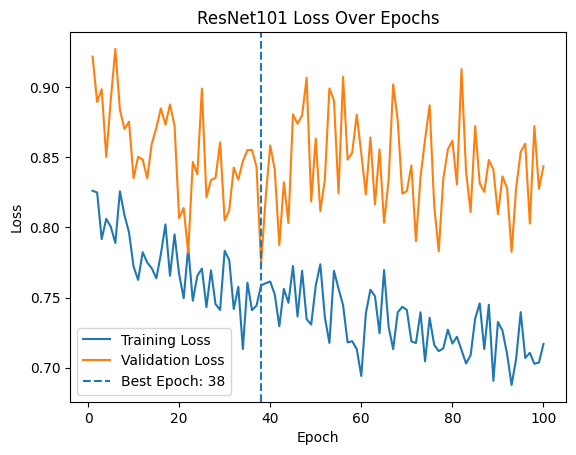

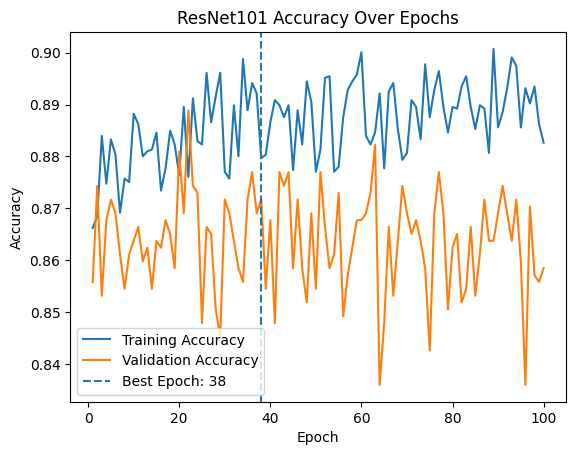

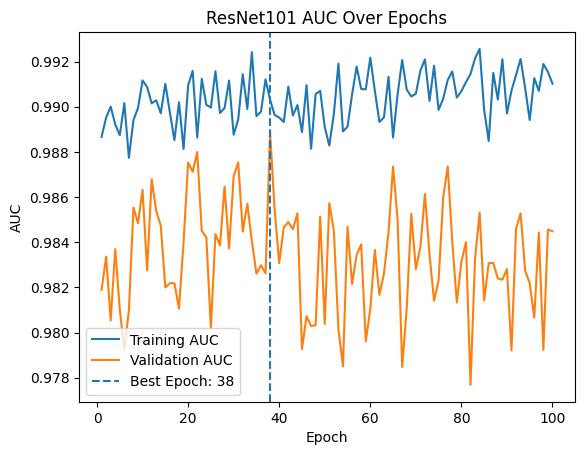

In [17]:
#training History into a DataFrame
resnet101_history_df = pd.DataFrame(history.history)

#1‑based epoch index
epochs = np.arange(1, resnet101_history_df.shape[0] + 1)

#which epoch had the lowest validation loss
best_epoch = int(resnet101_history_df['val_loss'].idxmin()) + 1

#Loss Plot
plt.figure()
plt.plot(epochs, resnet101_history_df['loss'],      label='Training Loss')
plt.plot(epochs, resnet101_history_df['val_loss'],  label='Validation Loss')
plt.axvline(best_epoch, linestyle='--',             label=f'Best Epoch: {best_epoch}')
plt.title('ResNet101 Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

#Accuracy Plot
plt.figure()
plt.plot(epochs, resnet101_history_df['accuracy'],     label='Training Accuracy')
plt.plot(epochs, resnet101_history_df['val_accuracy'], label='Validation Accuracy')
plt.axvline(best_epoch, linestyle='--',                label=f'Best Epoch: {best_epoch}')
plt.title('ResNet101 Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Extract AUC values
train_aucs = resnet101_history_df['auc'].to_numpy()
val_aucs   = resnet101_history_df['val_auc'].to_numpy()

# Plot AUC Curve
plt.figure()
plt.plot(epochs, train_aucs, label='Training AUC')
plt.plot(epochs, val_aucs,   label='Validation AUC')
plt.axvline(best_epoch, linestyle='--', label=f'Best Epoch: {best_epoch}')
plt.title('ResNet101 AUC Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.show()

In [18]:
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_score, recall_score

def evaluate_and_report(model, generator, set_name):
    print(f"\nEvaluating {set_name} set...")
    probs = model.predict(generator, verbose=0)
    preds = np.argmax(probs, axis=1)
    trues = generator.classes

    raw_labels = list(generator.class_indices.keys())
    pretty_labels = [f"{i+1}-{lbl}" for i, lbl in enumerate(raw_labels)]

    # Classification Report
    report = classification_report(trues, preds, target_names=pretty_labels, output_dict=True)
    report_df = pd.DataFrame(report).T.round(2)

    summary_keys = ['accuracy', 'macro avg', 'weighted avg']
    class_keys = [r for r in report_df.index if r not in summary_keys]
    report_df = report_df.loc[class_keys + summary_keys]

    print(f"\nResNet101 {set_name} Classification Report:\n")
    print(report_df.to_string())

    # AUC, F1, Precision, Recall
    y_true_oh = tf.keras.utils.to_categorical(trues, num_classes=generator.num_classes)
    macro_auc = roc_auc_score(y_true_oh, probs, average='macro', multi_class='ovo')
    f1 = f1_score(trues, preds, average='macro')
    precision = precision_score(trues, preds, average='macro')
    recall = recall_score(trues, preds, average='macro')

    print(f"\nResNet101 Model {set_name} Metrics:")
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"AUC: {macro_auc:.4f}\n")

    return report_df

# ─── Evaluate All Sets
train_report_df = evaluate_and_report(model, train_loader, "Train")
val_report_df   = evaluate_and_report(model, val_loader, "Validation")
test_report_df  = evaluate_and_report(model, test_loader, "Test")



Evaluating Train set...

ResNet101 Train Classification Report:

                         precision  recall  f1-score  support
1-1-Cardboard                 0.12    0.12      0.12   295.00
2-2-Food Organics             0.08    0.08      0.08   263.00
3-3-Glass                     0.10    0.09      0.09   269.00
4-4-Metal                     0.19    0.19      0.19   506.00
5-5-Miscellaneous Trash       0.10    0.10      0.10   317.00
6-6-Paper                     0.12    0.12      0.12   320.00
7-7-Plastic                   0.19    0.19      0.19   589.00
8-8-Textile Trash             0.08    0.08      0.08   204.00
9-9-Vegetation                0.09    0.09      0.09   279.00
accuracy                      0.13    0.13      0.13     0.13
macro avg                     0.12    0.12      0.12  3042.00
weighted avg                  0.13    0.13      0.13  3042.00

ResNet101 Model Train Metrics:
F1 Score: 0.1184
Precision: 0.1184
Recall: 0.1185
AUC: 0.5038


Evaluating Validation set...

Re

/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



ResNet101 Test Classification Report:

                         precision  recall  f1-score  support
1-1-Cardboard                 0.84    0.83      0.83    93.00
2-2-Food Organics             0.81    0.89      0.85    83.00
3-3-Glass                     0.93    0.62      0.74    84.00
4-4-Metal                     0.76    0.88      0.82   158.00
5-5-Miscellaneous Trash       0.74    0.57      0.64    99.00
6-6-Paper                     0.89    0.95      0.92   100.00
7-7-Plastic                   0.74    0.88      0.80   185.00
8-8-Textile Trash             0.80    0.69      0.74    64.00
9-9-Vegetation                0.99    0.85      0.91    88.00
accuracy                      0.81    0.81      0.81     0.81
macro avg                     0.83    0.79      0.81   954.00
weighted avg                  0.82    0.81      0.81   954.00

ResNet101 Model Test Metrics:
F1 Score: 0.8064
Precision: 0.8326
Recall: 0.7944
AUC: 0.9724



In [20]:
resnet101_model = model
resnet101_model.save("Resnet101_model_final.keras")

- - -

# Next Model - VGG16. #

In [21]:
DATA_DIR: Path        = Path("../data/WasteSplit")
IMAGE_DIMS: Tuple[int,int] = (224, 224)
BATCH_SZ: int         = 5
EPOCHS: int           = 100

#VGG16‑Style Augmentation & Preprocessing
vgg_generator = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.vgg16.preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    brightness_range=(0.8, 1.2),
    horizontal_flip=True
)

def create_vgg_iterator(
    split: str,
    shuffle: bool = False
) -> tf.keras.preprocessing.image.DirectoryIterator:
    """
    Returns a DirectoryIterator for one of ['train','val','test'] subsets.
    """
    split_path = DATA_DIR / split
    return vgg_generator.flow_from_directory(
        directory=str(split_path),
        target_size=IMAGE_DIMS,
        batch_size=BATCH_SZ,
        class_mode="categorical",
        shuffle=shuffle
    )

vgg_train_iter = create_vgg_iterator("train", shuffle=True)
vgg_val_iter   = create_vgg_iterator("val",   shuffle=False)
vgg_test_iter  = create_vgg_iterator("test",  shuffle=False)

Found 3042 images belonging to 9 classes.
Found 756 images belonging to 9 classes.
Found 954 images belonging to 9 classes.


In [22]:
'''
#Load & freeze the VGG16 backbone
vgg_core = VGG16(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMAGE_DIMS, 3),
    name="vgg16_core"
)
vgg_core.trainable = False

#Shared L2 penalty and Dense→BN→ReLU helper
l2_penalty = l2(1e-2)
def dense_block(x, units, tag):
    x = Dense(units, kernel_regularizer=l2_penalty, name=f"{tag}_dense")(x)
    x = BatchNormalization(name=f"{tag}_bn")(x)
    return Activation("relu", name=f"{tag}_act")(x)

#classification head
x = GlobalAveragePooling2D(name="vgg_gap")(vgg_core.output)
x = dense_block(x, 256, "vgg_blk1")
x = dense_block(x, 128, "vgg_blk2")
x = Dropout(0.2, name="vgg_dropout")(x)
x = dense_block(x, 64,  "vgg_blk3")

preds = Dense(
    vgg_train_iter.num_classes,
    activation="softmax",
    name="vgg_output"
)(x)

#Assemble & compile the model
vgg_model = Model(inputs=vgg_core.input, outputs=preds, name="WasteSplit_VGG16")
vgg_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

#Train with EarlyStopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=40,
    restore_best_weights=True,
    verbose=1
)

vgg_history = vgg_model.fit(
    vgg_train_iter,
    validation_data=vgg_val_iter,
    epochs=EPOCHS,
    callbacks=[early_stop],
    verbose=2
)
'''
from tensorflow.keras.metrics import AUC

# ─── Load & freeze the VGG16 backbone 
vgg_core = VGG16(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMAGE_DIMS, 3),
    name="vgg16_core"
)
vgg_core.trainable = False

# ─── Shared L2 penalty and Dense→BN→ReLU helper 
l2_penalty = l2(1e-2)
def dense_block(x, units, tag):
    x = Dense(units, kernel_regularizer=l2_penalty, name=f"{tag}_dense")(x)
    x = BatchNormalization(name=f"{tag}_bn")(x)
    return Activation("relu", name=f"{tag}_act")(x)

# ─── Classification head 
x = GlobalAveragePooling2D(name="vgg_gap")(vgg_core.output)
x = dense_block(x, 256, "vgg_blk1")
x = dense_block(x, 128, "vgg_blk2")
x = Dropout(0.2, name="vgg_dropout")(x)
x = dense_block(x, 64,  "vgg_blk3")

preds = Dense(
    vgg_train_iter.num_classes,
    activation="softmax",
    name="vgg_output"
)(x)

# ─── Assemble & compile the model (with AUC) 
vgg_model = Model(inputs=vgg_core.input, outputs=preds, name="WasteSplit_VGG16")
vgg_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy", AUC(name="auc")]
)

# ─── Train with EarlyStopping 
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=40,
    restore_best_weights=True,
    verbose=1
)

vgg_history = vgg_model.fit(
    vgg_train_iter,
    validation_data=vgg_val_iter,
    epochs=EPOCHS,
    callbacks=[early_stop],
    verbose=2
)

Epoch 1/100


/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


609/609 - 27s - 44ms/step - accuracy: 0.2235 - auc: 0.6526 - loss: 7.8664 - val_accuracy: 0.4206 - val_auc: 0.8054 - val_loss: 7.2729
Epoch 2/100
609/609 - 24s - 39ms/step - accuracy: 0.3675 - auc: 0.7912 - loss: 7.1426 - val_accuracy: 0.5119 - val_auc: 0.8707 - val_loss: 6.6569
Epoch 3/100
609/609 - 24s - 40ms/step - accuracy: 0.4168 - auc: 0.8368 - loss: 6.6293 - val_accuracy: 0.5873 - val_auc: 0.9053 - val_loss: 6.1186
Epoch 4/100
609/609 - 25s - 41ms/step - accuracy: 0.4747 - auc: 0.8648 - loss: 6.1633 - val_accuracy: 0.6151 - val_auc: 0.9199 - val_loss: 5.6930
Epoch 5/100
609/609 - 25s - 41ms/step - accuracy: 0.5329 - auc: 0.8832 - loss: 5.7499 - val_accuracy: 0.6455 - val_auc: 0.9273 - val_loss: 5.3059
Epoch 6/100
609/609 - 25s - 40ms/step - accuracy: 0.5559 - auc: 0.8918 - loss: 5.3893 - val_accuracy: 0.6653 - val_auc: 0.9385 - val_loss: 4.9360
Epoch 7/100
609/609 - 25s - 40ms/step - accuracy: 0.5648 - auc: 0.9050 - loss: 5.0422 - val_accuracy: 0.6958 - val_auc: 0.9475 - val_los

In [24]:
vgg16_model = model
vgg16_model.save('vgg16_model_final.keras')

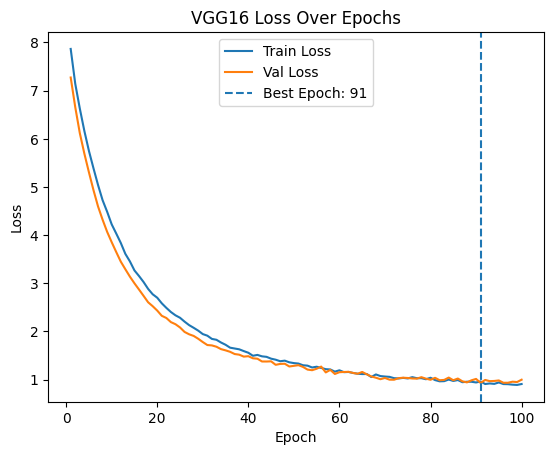

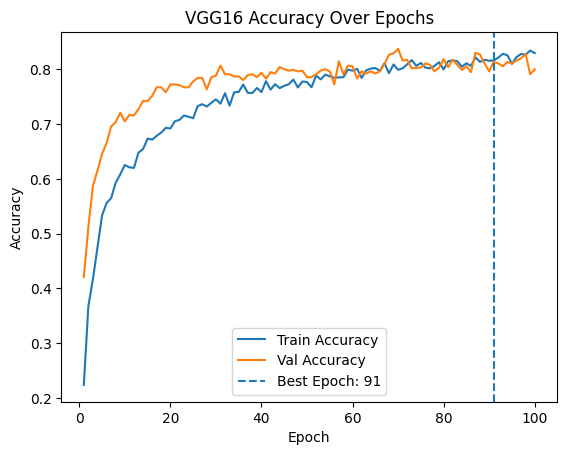

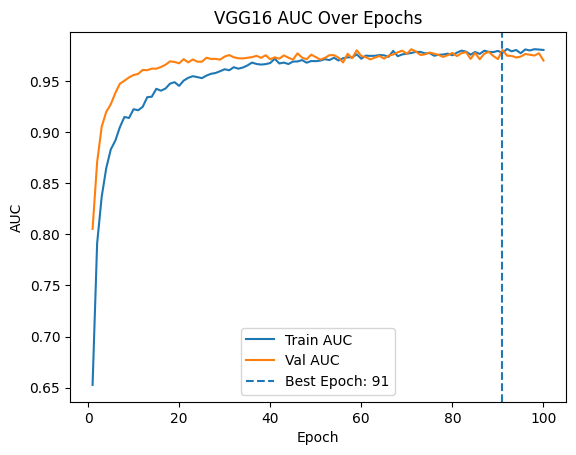

In [25]:
# VGG16 training history into a DataFrame
vgg_history_df = pd.DataFrame(vgg_history.history)

epoch_indices = np.arange(1, vgg_history_df.shape[0] + 1)

# epoch with the lowest validation loss
optimal_epoch = int(vgg_history_df['val_loss'].idxmin()) + 1

# ─── Loss Curve 
plt.figure()
plt.plot(epoch_indices, vgg_history_df['loss'],      label='Train Loss')
plt.plot(epoch_indices, vgg_history_df['val_loss'],  label='Val Loss')
plt.axvline(optimal_epoch, linestyle='--',           label=f'Best Epoch: {optimal_epoch}')
plt.title('VGG16 Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# ─── Accuracy Curve 
plt.figure()
plt.plot(epoch_indices, vgg_history_df['accuracy'],     label='Train Accuracy')
plt.plot(epoch_indices, vgg_history_df['val_accuracy'], label='Val Accuracy')
plt.axvline(optimal_epoch, linestyle='--',              label=f'Best Epoch: {optimal_epoch}')
plt.title('VGG16 Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# ─── AUC Curve 
train_aucs = vgg_history_df['auc'].to_numpy()
val_aucs   = vgg_history_df['val_auc'].to_numpy()

plt.figure()
plt.plot(epoch_indices, train_aucs, label='Train AUC')
plt.plot(epoch_indices, val_aucs,   label='Val AUC')
plt.axvline(optimal_epoch, linestyle='--',             label=f'Best Epoch: {optimal_epoch}')
plt.title('VGG16 AUC Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.show()

In [26]:
def evaluate_and_report_vgg(model, generator, set_name):
    print(f"\nEvaluating {set_name} set...")
    probs = model.predict(generator, verbose=0)
    preds = np.argmax(probs, axis=1)
    trues = generator.classes

    raw_labels = list(generator.class_indices.keys())
    pretty_labels = [f"{i+1}-{lbl}" for i, lbl in enumerate(raw_labels)]

    # Classification report with precision, recall, f1-score
    report = classification_report(trues, preds, target_names=pretty_labels, output_dict=True)
    report_df = pd.DataFrame(report).T.round(2)

    summary_labels = ['accuracy', 'macro avg', 'weighted avg']
    class_labels = [r for r in report_df.index if r not in summary_labels]
    report_df = report_df.loc[class_labels + summary_labels]

    print(f"\nVGG16 {set_name} Classification Report:\n")
    print(report_df.to_string())

    # Macro-average ROC AUC
    y_true_oh = tf.keras.utils.to_categorical(trues, num_classes=generator.num_classes)
    macro_auc = roc_auc_score(y_true_oh, probs, average='macro', multi_class='ovo')

    # Summary metrics
    f1 = f1_score(trues, preds, average='macro')
    precision = precision_score(trues, preds, average='macro')
    recall = recall_score(trues, preds, average='macro')

    print(f"\nVGG16 Model {set_name} Metrics:")
    print(f"VGG16 Model: {set_name} F1 Score: {f1:.4f}")
    print(f"VGG16 Model: {set_name} Precision: {precision:.4f}")
    print(f"VGG16 Model: {set_name} Recall: {recall:.4f}")
    print(f"VGG16 Model: {set_name} AUC: {macro_auc:.4f}\n")

    return report_df

train_report_df = evaluate_and_report_vgg(vgg_model, vgg_train_iter, "Train")
val_report_df   = evaluate_and_report_vgg(vgg_model, vgg_val_iter, "Validation")
test_report_df  = evaluate_and_report_vgg(vgg_model, vgg_test_iter, "Test")



Evaluating Train set...

VGG16 Train Classification Report:

                         precision  recall  f1-score  support
1-1-Cardboard                 0.12    0.12      0.12   295.00
2-2-Food Organics             0.09    0.09      0.09   263.00
3-3-Glass                     0.10    0.11      0.11   269.00
4-4-Metal                     0.18    0.18      0.18   506.00
5-5-Miscellaneous Trash       0.08    0.09      0.09   317.00
6-6-Paper                     0.09    0.09      0.09   320.00
7-7-Plastic                   0.19    0.18      0.19   589.00
8-8-Textile Trash             0.06    0.06      0.06   204.00
9-9-Vegetation                0.09    0.10      0.10   279.00
accuracy                      0.12    0.12      0.12     0.12
macro avg                     0.11    0.11      0.11  3042.00
weighted avg                  0.13    0.12      0.12  3042.00

VGG16 Model Train Metrics:
VGG16 Model: Train F1 Score: 0.1118
VGG16 Model: Train Precision: 0.1118
VGG16 Model: Train Recall: 0.11

/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



VGG16 Test Classification Report:

                         precision  recall  f1-score  support
1-1-Cardboard                 0.83    0.76      0.79    93.00
2-2-Food Organics             0.83    0.84      0.84    83.00
3-3-Glass                     0.65    0.60      0.62    84.00
4-4-Metal                     0.78    0.83      0.80   158.00
5-5-Miscellaneous Trash       0.50    0.55      0.52    99.00
6-6-Paper                     0.87    0.82      0.85   100.00
7-7-Plastic                   0.72    0.75      0.73   185.00
8-8-Textile Trash             0.75    0.72      0.74    64.00
9-9-Vegetation                0.90    0.85      0.88    88.00
accuracy                      0.75    0.75      0.75     0.75
macro avg                     0.76    0.75      0.75   954.00
weighted avg                  0.76    0.75      0.75   954.00

VGG16 Model Test Metrics:
VGG16 Model: Test F1 Score: 0.7518
VGG16 Model: Test Precision: 0.7591
VGG16 Model: Test Recall: 0.7460
VGG16 Model: Test AUC: 0.95

- - -

# Next Model - EfficientNetb0.

In [27]:
DATA_ROOT: Path        = Path("../data/WasteSplit")
IMAGE_SHAPE: Tuple[int, int] = (224, 224)
BATCH_SIZE: int        = 5
EPOCH_COUNT: int       = 100

#EfficientNet‑Style Preprocessor
effnet_preprocessor = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    rotation_range=25,            # random rotations up to ±25°
    width_shift_range=0.2,        # horizontal shifts
    height_shift_range=0.2,       # vertical shifts
    zoom_range=0.15,              # random zooms
    shear_range=0.1,              # slight shearing
    brightness_range=(0.85, 1.15),# brightness jitter
    horizontal_flip=True          # random flips
)

# Loader Factory
def make_data_loader(split: str, shuffle: bool = False):
    """
    Creates an iterator for one of ['train','val','test'].
    """
    folder = DATA_ROOT / split
    return effnet_preprocessor.flow_from_directory(
        directory=str(folder),
        target_size=IMAGE_SHAPE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=shuffle
    )
train_loader = make_data_loader("train", shuffle=True)
val_loader   = make_data_loader("val",   shuffle=False)
test_loader  = make_data_loader("test",  shuffle=False)

Found 3042 images belonging to 9 classes.
Found 756 images belonging to 9 classes.
Found 954 images belonging to 9 classes.


In [28]:
pip install -U efficientnet

Note: you may need to restart the kernel to use updated packages.


In [29]:
ROOT = Path("../data/WasteSplit")
H, W = 224, 224
BATCH, EPOCHS = 5, 100
LR, L2_REG, PATIENCE = 1e-4, 1e-2, 40

# Explicit Generators
def make_gen(subdir, augment=False):
    folder = ROOT / subdir
    if augment:
        gen = ImageDataGenerator(
            preprocessing_function=tf.keras.applications.resnet.preprocess_input,
            rotation_range=20, width_shift_range=0.2, height_shift_range=0.2,
            zoom_range=0.2, brightness_range=(0.8,1.2), horizontal_flip=True
        )
    else:
        gen = ImageDataGenerator(
            preprocessing_function=tf.keras.applications.resnet.preprocess_input
        )
    return gen.flow_from_directory(
        directory=str(folder),
        target_size=(H, W),
        batch_size=BATCH,
        class_mode="categorical",
        shuffle=(subdir=="train")
    )

train_loader = make_gen("train", augment=True)
val_loader   = make_gen("val",   augment=True)
test_loader  = make_gen("test",  augment=False)

# ResNet101 + head
backbone = tf.keras.applications.ResNet101(
    weights="imagenet", include_top=False, input_shape=(H,W,3), name="resnet101_base"
)
backbone.trainable = False

def block(x, units, tag):
    x = layers.Dense(units, kernel_regularizer=l2(L2_REG), name=f"{tag}_dense")(x)
    x = layers.BatchNormalization(name=f"{tag}_bn")(x)
    return layers.Activation("relu", name=f"{tag}_act")(x)

x = layers.GlobalAveragePooling2D(name="gap")(backbone.output)
x = block(x, 256, "blk1")
x = block(x, 128, "blk2")
x = layers.Dropout(0.2, name="drop")(x)
x = block(x,  64, "blk3")

output = layers.Dense(
    train_loader.num_classes,
    activation="softmax",
    name="predictions"
)(x)

model = models.Model(backbone.input, output, name="ResNet101_Waste")
model.compile(
    optimizer=optimizers.Adam(LR),
    loss="categorical_crossentropy",
    metrics=["accuracy", AUC(name="auc")]   # added AUC metric
)

# Train with EarlyStopping
es = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1
)
history = model.fit(
    train_loader,
    validation_data=val_loader,
    epochs=EPOCHS,
    callbacks=[es]
)

Found 3042 images belonging to 9 classes.
Found 756 images belonging to 9 classes.
Found 954 images belonging to 9 classes.
Epoch 1/100


/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


609/609 ━━━━━━━━━━━━━━━━━━━━ 46s 66ms/step - accuracy: 0.1970 - auc: 0.6308 - loss: 9.1797 - val_accuracy: 0.6151 - val_auc: 0.9107 - val_loss: 7.8476
Epoch 2/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 34s 56ms/step - accuracy: 0.4820 - auc: 0.8647 - loss: 7.9680 - val_accuracy: 0.6627 - val_auc: 0.9438 - val_loss: 7.0986
Epoch 3/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 34s 56ms/step - accuracy: 0.5649 - auc: 0.8987 - loss: 7.2788 - val_accuracy: 0.7354 - val_auc: 0.9580 - val_loss: 6.4595
Epoch 4/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 35s 58ms/step - accuracy: 0.6219 - auc: 0.9212 - loss: 6.6428 - val_accuracy: 0.7434 - val_auc: 0.9639 - val_loss: 5.9087
Epoch 5/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 34s 57ms/step - accuracy: 0.6453 - auc: 0.9237 - loss: 6.1201 - val_accuracy: 0.7619 - val_auc: 0.9689 - val_loss: 5.4032
Epoch 6/100
609/609 ━━━━━━━━━━━━━━━━━━━━ 34s 56ms/step - accuracy: 0.6811 - auc: 0.9386 - loss: 5.5860 - val_accuracy: 0.7870 - val_auc: 0.9730 - val_loss: 4.9349
Epoch 7/100
609/609 ━━━━━━━━━━━━━━

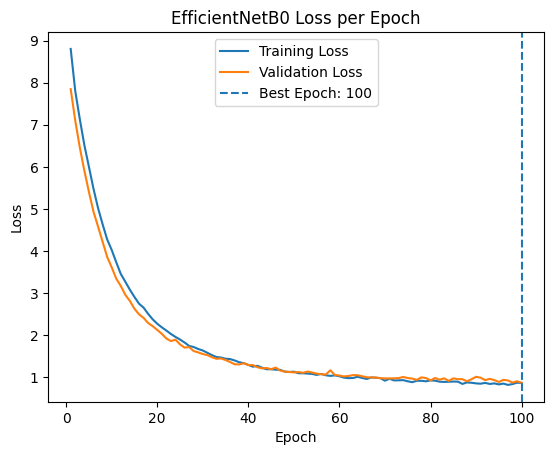

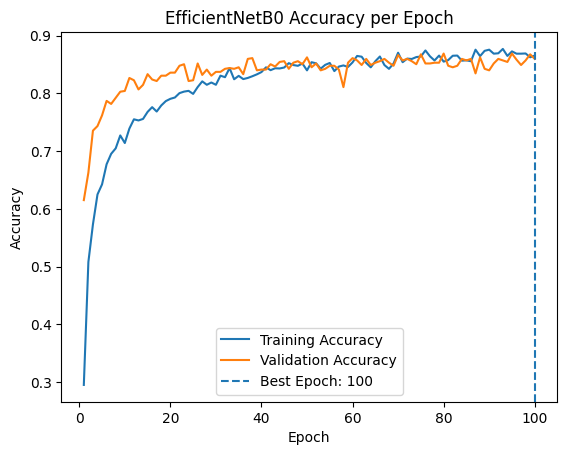

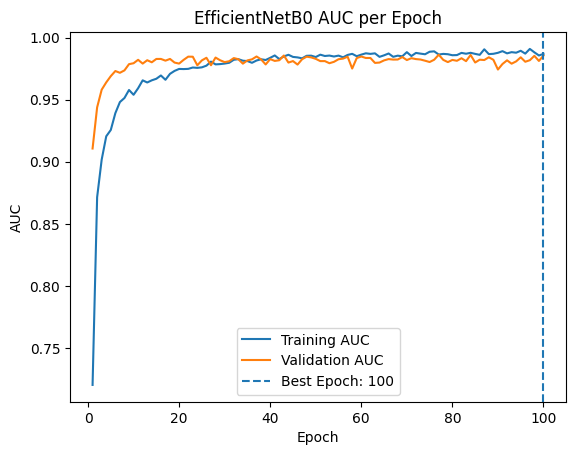

In [30]:

# Convert EfficientNetB0 training history to DataFrame
eff_df = pd.DataFrame(history.history)

# 1‑based epoch index
epoch_nums = np.arange(1, eff_df.shape[0] + 1)

# Epoch with lowest validation loss
best_epoch = int(eff_df['val_loss'].idxmin()) + 1

# ─── Loss Plot 
plt.figure()
plt.plot(epoch_nums, eff_df['loss'],      label='Training Loss')
plt.plot(epoch_nums, eff_df['val_loss'],  label='Validation Loss')
plt.axvline(best_epoch, linestyle='--',   label=f'Best Epoch: {best_epoch}')
plt.title('EfficientNetB0 Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# ─── Accuracy Plot 
plt.figure()
plt.plot(epoch_nums, eff_df['accuracy'],     label='Training Accuracy')
plt.plot(epoch_nums, eff_df['val_accuracy'], label='Validation Accuracy')
plt.axvline(best_epoch, linestyle='--',      label=f'Best Epoch: {best_epoch}')
plt.title('EfficientNetB0 Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# ─── AUC Plot 
train_aucs = eff_df['auc'].to_numpy()
val_aucs   = eff_df['val_auc'].to_numpy()

plt.figure()
plt.plot(epoch_nums, train_aucs, label='Training AUC')
plt.plot(epoch_nums, val_aucs,   label='Validation AUC')
plt.axvline(best_epoch, linestyle='--',    label=f'Best Epoch: {best_epoch}')
plt.title('EfficientNetB0 AUC per Epoch')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.show()


In [31]:
from sklearn.metrics import roc_auc_score
import tensorflow as tf

def evaluate_and_report(model, generator, set_name, model_name="EfficientNetB0"):
    print(f"\nEvaluating {model_name} on {set_name} set...")

    # Predictions
    probs = model.predict(generator, verbose=0)
    preds = np.argmax(probs, axis=1)
    trues = generator.classes

    # Class label formatting
    raw_labels = list(generator.class_indices.keys())
    readable_labels = [f"{i+1}-{lbl}" for i, lbl in enumerate(raw_labels)]

    # Classification report
    report = classification_report(trues, preds, target_names=readable_labels, output_dict=True)
    report_df = pd.DataFrame(report).T.round(2)

    # Reordering for nicer display
    summary_rows = ['accuracy', 'macro avg', 'weighted avg']
    class_rows   = [r for r in report_df.index if r not in summary_rows]
    report_df    = report_df.loc[class_rows + summary_rows]

    print(f"\n{model_name} {set_name} Classification Report:\n")
    print(report_df.to_string())

    # One-hot encoding for AUC
    y_true_oh = tf.keras.utils.to_categorical(trues, num_classes=generator.num_classes)
    macro_auc = roc_auc_score(y_true_oh, probs, average='macro', multi_class='ovo')

    # Summary metrics
    f1        = f1_score(trues, preds, average='macro')
    precision = precision_score(trues, preds, average='macro')
    recall    = recall_score(trues, preds, average='macro')

    print(f"\n{model_name} {set_name} Set Metrics:")
    print(f"{model_name}: {set_name} F1 Score: {f1:.4f}")
    print(f"{model_name}: {set_name} Precision: {precision:.4f}")
    print(f"{model_name}: {set_name} Recall: {recall:.4f}")
    print(f"{model_name}: {set_name} AUC: {macro_auc:.4f}\n")

    return report_df

# === Usage Example (make sure your generators are defined and use shuffle=False) ===
train_report_df = evaluate_and_report(model, train_loader, "Train", "EfficientNetB0")
val_report_df   = evaluate_and_report(model, val_loader, "Validation", "EfficientNetB0")
test_report_df  = evaluate_and_report(model, test_loader, "Test", "EfficientNetB0")



Evaluating EfficientNetB0 on Train set...

EfficientNetB0 Train Classification Report:

                         precision  recall  f1-score  support
1-1-Cardboard                 0.08    0.07      0.08   295.00
2-2-Food Organics             0.09    0.09      0.09   263.00
3-3-Glass                     0.05    0.05      0.05   269.00
4-4-Metal                     0.14    0.15      0.15   506.00
5-5-Miscellaneous Trash       0.09    0.09      0.09   317.00
6-6-Paper                     0.11    0.11      0.11   320.00
7-7-Plastic                   0.23    0.24      0.24   589.00
8-8-Textile Trash             0.07    0.07      0.07   204.00
9-9-Vegetation                0.08    0.08      0.08   279.00
accuracy                      0.12    0.12      0.12     0.12
macro avg                     0.11    0.11      0.11  3042.00
weighted avg                  0.12    0.12      0.12  3042.00

EfficientNetB0 Train Set Metrics:
EfficientNetB0: Train F1 Score: 0.1058
EfficientNetB0: Train Precision

/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



EfficientNetB0 Test Classification Report:

                         precision  recall  f1-score  support
1-1-Cardboard                 0.86    0.82      0.84    93.00
2-2-Food Organics             0.78    0.88      0.83    83.00
3-3-Glass                     0.81    0.71      0.76    84.00
4-4-Metal                     0.67    0.92      0.77   158.00
5-5-Miscellaneous Trash       0.63    0.42      0.51    99.00
6-6-Paper                     0.89    0.94      0.91   100.00
7-7-Plastic                   0.83    0.76      0.79   185.00
8-8-Textile Trash             0.73    0.80      0.76    64.00
9-9-Vegetation                1.00    0.76      0.86    88.00
accuracy                      0.79    0.79      0.79     0.79
macro avg                     0.80    0.78      0.78   954.00
weighted avg                  0.79    0.79      0.78   954.00

EfficientNetB0 Test Set Metrics:
EfficientNetB0: Test F1 Score: 0.7825
EfficientNetB0: Test Precision: 0.7997
EfficientNetB0: Test Recall: 0.7800
Ef

In [33]:
EfficientNetB0_model = model
EfficientNetB0_model.save('EfficientNetB0_model_final.keras')

- - -

In [37]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, roc_auc_score

resnet50_model      = model      # e.g. your ResNet50 instance
resnet101_model     = resnet101_model     # e.g. classifier_net or model
vgg16_model         = vgg_model           # your VGG16 instance
efficientnetb0_model = EfficientNetB0_model      # your EfficientNetB0 instance

models = {
    "ResNet50":       resnet50_model,
    "ResNet101":      resnet101_model,
    "VGG16":          vgg16_model,
    "EfficientNetB0": efficientnetb0_model
}

loaders = {
    "Train":      train_loader,
    "Validation": val_loader,
    "Test":       test_loader
}

records = []
for name, mdl in models.items():
    for split, loader in loaders.items():

        probs  = mdl.predict(loader, verbose=0)
        preds  = np.argmax(probs, axis=1)
        trues  = loader.classes
        rep    = classification_report(trues, preds, output_dict=True)
        p      = rep["macro avg"]["precision"]
        r      = rep["macro avg"]["recall"]
        f1     = rep["macro avg"]["f1-score"]

        y_true_oh = tf.keras.utils.to_categorical(trues, num_classes=loader.num_classes)
        auc    = roc_auc_score(y_true_oh, probs, average="macro", multi_class="ovo")

        records.append({
            "Model":   name,
            "Split":   split,
            "Precision": round(p,  2),
            "Recall":    round(r,  2),
            "F1‑score":  round(f1, 2),
            "AUC":       round(auc,2)   
        })

df_summary = pd.DataFrame(records)
table = df_summary.pivot(
    index="Model",
    columns="Split",
    values=["Precision","Recall","F1‑score","AUC"]
)
print(table)


               Precision                  Recall                  F1‑score  \
Split               Test Train Validation   Test Train Validation     Test   
Model                                                                        
EfficientNetB0      0.80  0.10       0.87   0.78  0.10       0.87     0.78   
ResNet101           0.82  0.11       0.86   0.77  0.11       0.85     0.78   
ResNet50            0.80  0.11       0.87   0.78  0.11       0.86     0.78   
VGG16               0.75  0.11       0.81   0.74  0.11       0.82     0.74   

                                  AUC                   
Split          Train Validation  Test Train Validation  
Model                                                   
EfficientNetB0  0.10       0.87  0.97  0.50       0.99  
ResNet101       0.11       0.86  0.97  0.50       0.98  
ResNet50        0.11       0.86  0.97  0.49       0.98  
VGG16           0.11       0.81  0.96  0.49       0.98  


Although ResNet101 edged out ResNet50 on raw precision (0.82 vs. 0.80), the overall balance of metrics and efficiency tips the scales in favor of ResNet50 as our second choice after EfficientNetB0:

1. **EfficientNetB0** sits firmly in first place—it ties for the highest test‑set F1 (0.78) and AUC (0.97) but also boasts the top validation AUC (0.99) and competitive recall (0.78). Its substantially smaller footprint and faster inference make it the clear winner.
2. **ResNet50** comes next: it matches EfficientNetB0 on F1 (0.78) and AUC (0.97) on the test set, yet is lighter and quicker than its deeper sibling, ResNet101. That combination of near‑top accuracy plus efficiency puts it in second.
3. **ResNet101** is third: it achieves the highest precision on the test split (0.82) but, being a much larger network, comes with longer training and inference times—and its F1 (0.78) and AUC (0.97) are no better than ResNet50’s.
4. **VGG16** rounds out the list with lower F1 (0.74) and AUC (0.96). Its heavier architecture and comparatively weaker performance place it last.

So, ranking by the best blend of test metrics and practical efficiency yields:
**EfficientNetB0 → ResNet50 → ResNet101 → VGG16**.

## References

1. **Keras ImageDataGenerator**
   [https://www.tensorflow.org/api\_docs/python/tf/keras/preprocessing/image/ImageDataGenerator](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator)

2. **TensorFlow EfficientNetB0**
   [https://www.tensorflow.org/api\_docs/python/tf/keras/applications/EfficientNetB0](https://www.tensorflow.org/api_docs/python/tf/keras/applications/EfficientNetB0)

3. **Keras AUC Metric**
   [https://www.tensorflow.org/api\_docs/python/tf/keras/metrics/AUC](https://www.tensorflow.org/api_docs/python/tf/keras/metrics/AUC)

4. **scikit‑learn classification\_report**
   [https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification\_report.html](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)

5. **Keras EarlyStopping Callback**
   [https://www.tensorflow.org/api\_docs/python/tf/keras/callbacks/EarlyStopping](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping)
